In [2]:
import sys
sys.path.insert(0, '/home/jovyan/.local/lib/python3.12/site-packages')

[*********************100%***********************]  1 of 1 completed


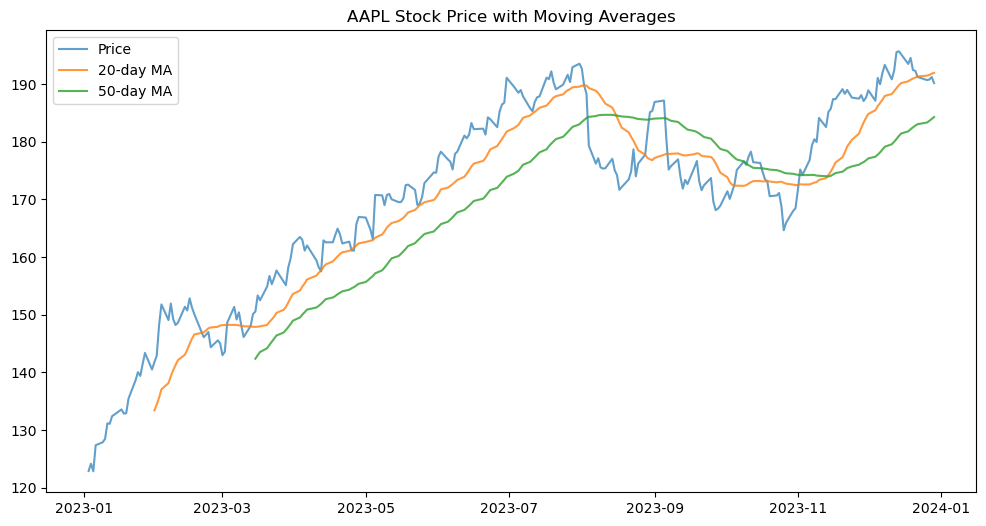

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

df = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

plt.figure(figsize=(12,6))
plt.plot(df["Close"], label="Price", alpha=0.7)
plt.plot(df["MA20"], label="20-day MA", alpha=0.8)
plt.plot(df["MA50"], label="50-day MA", alpha=0.8)
plt.title("AAPL Stock Price with Moving Averages")
plt.legend()
plt.savefig("aapl_analysis.png")
plt.show()

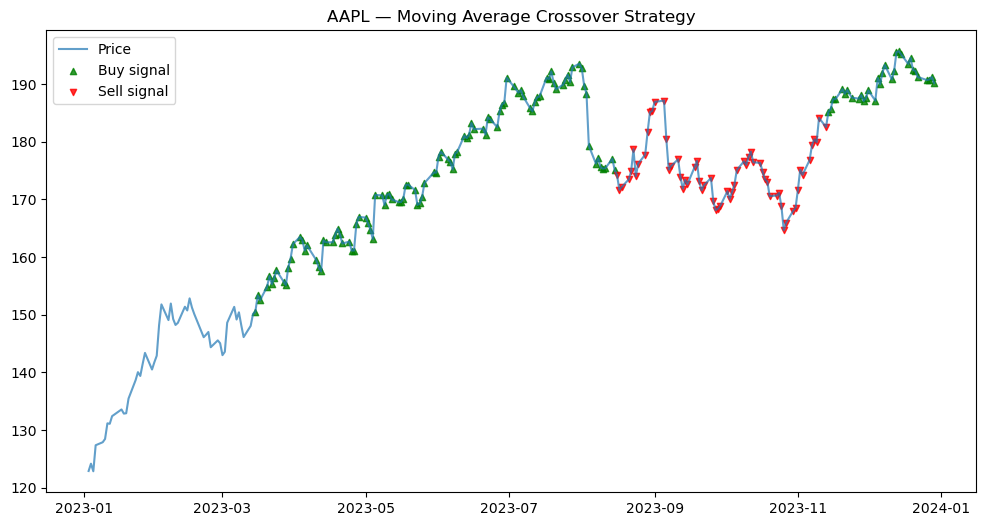

In [4]:
# Generate buy/sell signals
df["Signal"] = 0
df.loc[df["MA20"] > df["MA50"], "Signal"] = 1   # buy
df.loc[df["MA20"] < df["MA50"], "Signal"] = -1  # sell

# Separate into buy and sell points
buy = df[df["Signal"] == 1]
sell = df[df["Signal"] == -1]

# Plot with signals
plt.figure(figsize=(12,6))
plt.plot(df["Close"], label="Price", alpha=0.7)
plt.scatter(buy.index, buy["Close"], marker="^", 
            color="green", label="Buy signal", alpha=0.8, s=20)
plt.scatter(sell.index, sell["Close"], marker="v", 
            color="red", label="Sell signal", alpha=0.8, s=20)
plt.title("AAPL — Moving Average Crossover Strategy")
plt.legend()
plt.savefig("signals.png")
plt.show()

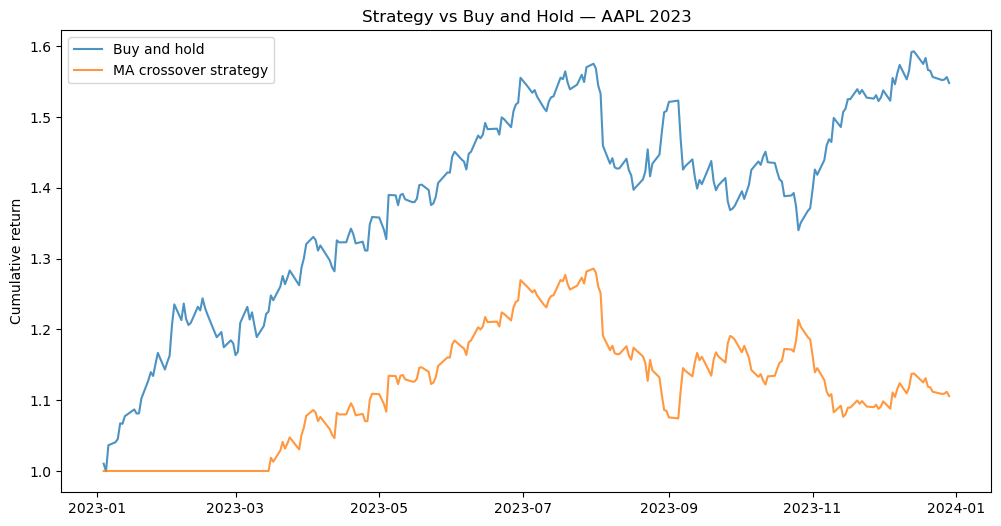

Buy and hold return: 54.8%
MA crossover return: 10.6%


In [5]:
# Backtest the strategy
df["Daily_Return"] = df["Close"].pct_change()
df["Strategy_Return"] = df["Daily_Return"] * df["Signal"].shift(1)

# Cumulative returns
df["Cumulative_Market"] = (1 + df["Daily_Return"]).cumprod()
df["Cumulative_Strategy"] = (1 + df["Strategy_Return"]).cumprod()

# Plot comparison
plt.figure(figsize=(12,6))
plt.plot(df["Cumulative_Market"], label="Buy and hold", alpha=0.8)
plt.plot(df["Cumulative_Strategy"], label="MA crossover strategy", alpha=0.8)
plt.title("Strategy vs Buy and Hold — AAPL 2023")
plt.ylabel("Cumulative return")
plt.legend()
plt.savefig("backtest.png")
plt.show()

# Print results
total_market = df["Cumulative_Market"].iloc[-1] - 1
total_strategy = df["Cumulative_Strategy"].iloc[-1] - 1
print(f"Buy and hold return: {total_market:.1%}")
print(f"MA crossover return: {total_strategy:.1%}")